# Exploratory Data Analysis (EDA) - TrainPulse
Notebook ini melakukan eksplorasi pada dataset TrainPulse yang diambil dari `data/trainpulse.db`. Fokus utamanya adalah memahami distribusi data dan korelasi antar variabel, terutama terkait `attendance_rate` dan `status_lulus`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
base_dir = os.path.dirname(os.path.abspath(''))
db_path = os.path.join(base_dir, 'data', 'trainpulse.db')

conn = sqlite3.connect(db_path)

query = '''
SELECT 
    p.nama, p.departemen,
    tp.nama_program, tp.kategori, tp.durasi_hari,
    ts.batch,
    a.pretest_score, a.posttest_score, a.status_lulus,
    (SELECT COUNT(*) FROM attendances att WHERE att.session_id = a.session_id AND att.participant_id = a.participant_id AND att.status_hadir = 1) * 1.0 / tp.durasi_hari AS attendance_rate
FROM assessments a
JOIN participants p ON a.participant_id = p.id
JOIN training_sessions ts ON a.session_id = ts.id
JOIN training_programs tp ON ts.program_id = tp.id
'''

df = pd.read_sql_query(query, conn)
conn.close()

df.head()

,nama,departemen,nama_program,kategori,durasi_hari,batch,pretest_score,posttest_score,status_lulus,attendance_rate
0,Bakiman Novitasari,IT,Effective Communication,Soft Skills,3,1,71.34,89.44,1,1.000000
1,T. Legawa Manullang,Finance,Effective Communication,Soft Skills,3,1,48.19,53.36,0,0.666667
2,Pia Sitompul,Finance,Effective Communication,Soft Skills,3,1,59.81,79.02,1,1.000000
3,Karman Suryatmi,Marketing,Effective Communication,Soft Skills,3,1,47.31,65.23,0,1.000000
4,dr. Zamira Gunawan,Marketing,Effective Communication,Soft Skills,3,1,64.14,74.65,1,0.666667


## Kualitas Data
Memeriksa missing values dan tipe data.

In [2]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nama             1521 non-null   str    
 1   departemen       1521 non-null   str    
 2   nama_program     1521 non-null   str    
 3   kategori         1521 non-null   str    
 4   durasi_hari      1521 non-null   int64  
 5   batch            1521 non-null   int64  
 6   pretest_score    1521 non-null   float64
 7   posttest_score   1521 non-null   float64
 8   status_lulus     1521 non-null   int64  
 9   attendance_rate  1521 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 197.6 KB

Missing values:
 nama               0
departemen         0
nama_program       0
kategori           0
durasi_hari        0
batch              0
pretest_score      0
posttest_score     0
status_lulus       0
attendance_rate    0
dtype: int64


## Distribusi Attendance Rate
Melihat bagaimana distribusi tingkat kehadiran (attendance rate) berdasarkan departemen dan kategori program.

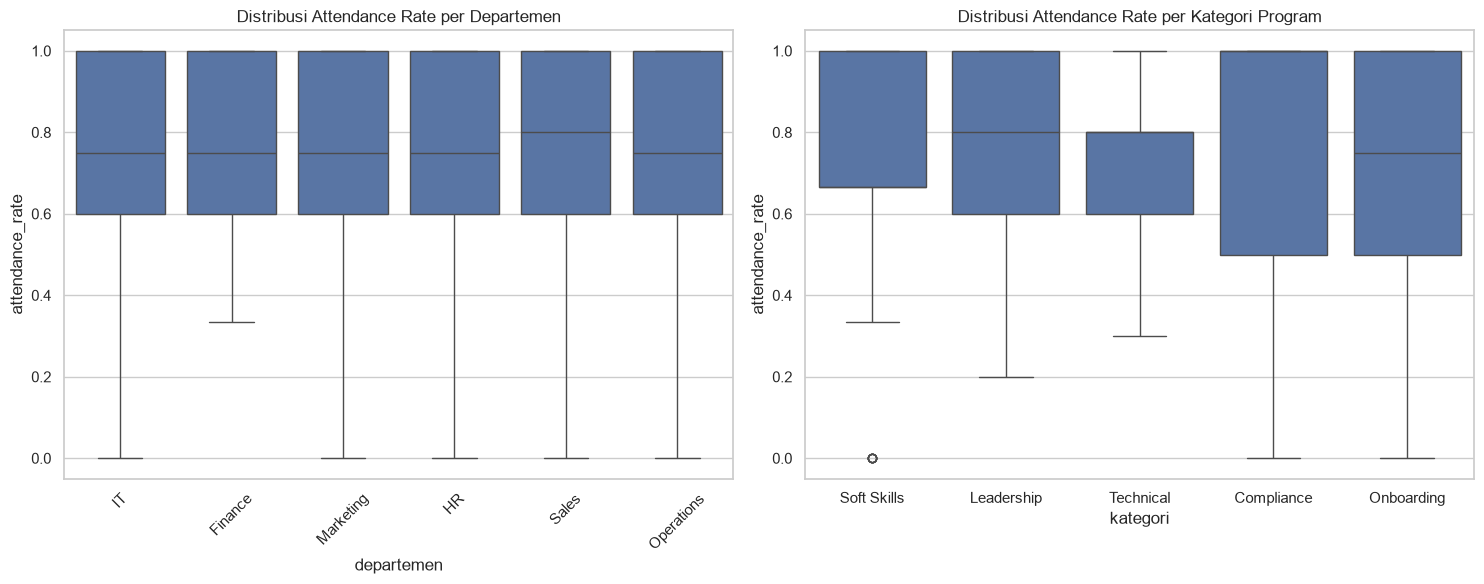

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='departemen', y='attendance_rate', ax=axes[0])
axes[0].set_title('Distribusi Attendance Rate per Departemen')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='kategori', y='attendance_rate', ax=axes[1])
axes[1].set_title('Distribusi Attendance Rate per Kategori Program')

plt.tight_layout()
plt.show()

**Insight:**
- Sebagian besar peserta memiliki `attendance_rate` yang cukup tinggi.
- Distribusi antar departemen relatif seimbang, menunjukkan tidak ada departemen tertentu yang sangat tertinggal dalam kehadiran.
- Kategori 'Technical' mungkin memiliki sebaran kehadiran yang sedikit berbeda dibandingkan 'Soft Skills', namun secara umum cukup merata.

## Korelasi: Attendance Rate vs Pretest/Posttest & Kelulusan
Mari kita lihat apakah ada korelasi antara kehadiran dengan nilai pretest, posttest, dan kemungkinan lulus.

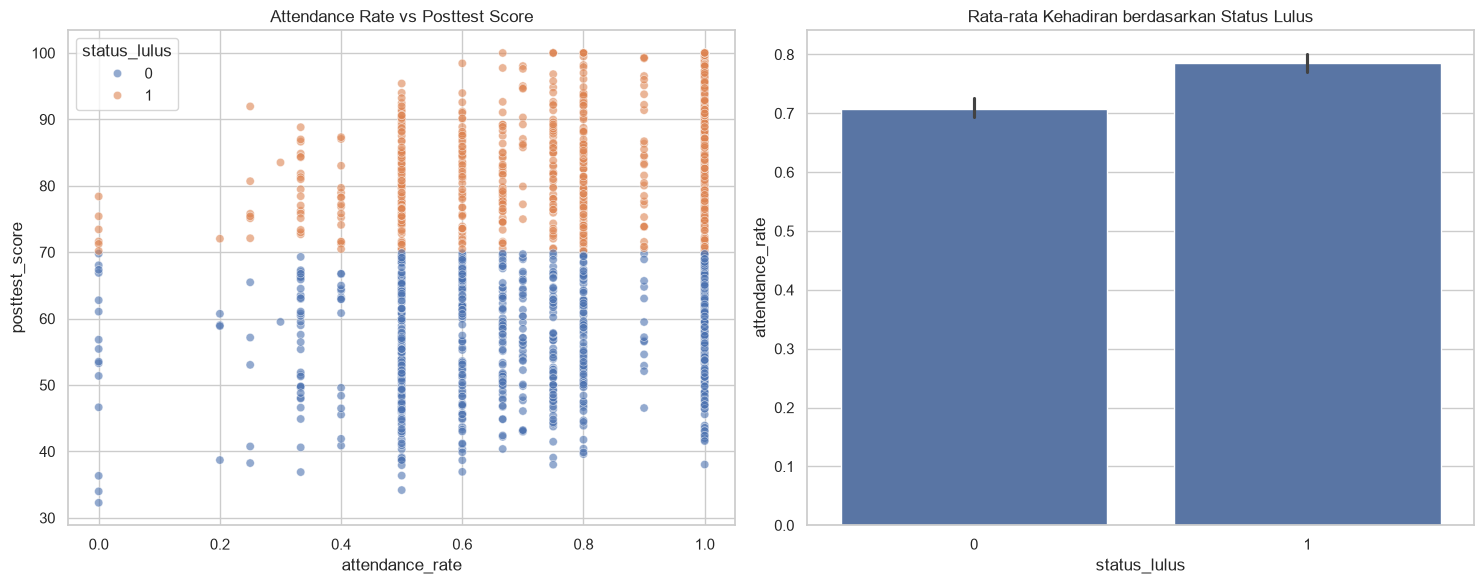

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot: Attendance vs Posttest
sns.scatterplot(data=df, x='attendance_rate', y='posttest_score', hue='status_lulus', alpha=0.6, ax=axes[0])
axes[0].set_title('Attendance Rate vs Posttest Score')

# Bar plot: Lulus vs Tidak Lulus based on average Attendance
sns.barplot(data=df, x='status_lulus', y='attendance_rate', ax=axes[1])
axes[1].set_title('Rata-rata Kehadiran berdasarkan Status Lulus')

plt.tight_layout()
plt.show()

**Insight:**
- Terdapat korelasi positif yang jelas antara `attendance_rate` dan `posttest_score`. Peserta dengan tingkat kehadiran yang tinggi cenderung mendapatkan nilai posttest yang lebih baik.
- Peserta yang lulus (status_lulus = 1) secara rata-rata memiliki tingkat kehadiran yang jauh lebih tinggi dibandingkan peserta yang tidak lulus. Hal ini mengonfirmasi hipotesis bahwa kehadiran adalah fitur yang sangat prediktif terhadap kelulusan training.